# Credit Risk Scoring & Loan Default Prediction

**Author:** Data Analyst Project
**Goal:** Predict whether a customer will default on a loan using basic customer, income, and credit history data.

This notebook walks through a simple, beginner-friendly machine learning workflow:
loading data, cleaning it, exploring it visually, building two basic classification
models, and evaluating which features matter most.

## 1. Import Libraries

We start by importing the basic libraries needed for data handling, visualization, and modeling.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Make plots look a little nicer
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)


## 2. Load Dataset

We load the customer loan dataset from a CSV file.

In [2]:
# Load the dataset
df = pd.read_csv("loan_data.csv")

# Preview the first 5 rows
df.head()


,Age,Income,LoanAmount,CreditScore,EmploymentStatus,LoanTerm,PreviousDefaults,DebtToIncomeRatio,MaritalStatus,Education,Default
0,54,48314.06,10689.27,576.0,Unemployed,36,1,0.35,Single,Masters,0
1,36,44622.81,10249.51,747.0,Employed,36,0,0.45,Single,High School,0
2,30,58067.49,29370.89,597.0,Employed,24,0,0.34,Divorced,High School,1
3,56,64779.36,25230.93,547.0,Employed,24,0,0.15,Single,High School,0
4,53,56730.17,17798.40,593.0,Self-Employed,48,2,0.41,Single,Masters,1


## 3. Basic Data Exploration

Before doing anything else, let's understand the structure of the data:
its size, data types, summary statistics, missing values, and duplicates.

In [3]:
# Shape of the dataset (rows, columns)
print("Dataset shape:", df.shape)


Dataset shape: (1010, 11)


In [4]:
# Data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1010 non-null   int64  
 1   Income             994 non-null    float64
 2   LoanAmount         1010 non-null   float64
 3   CreditScore        995 non-null    float64
 4   EmploymentStatus   994 non-null    str    
 5   LoanTerm           1010 non-null   int64  
 6   PreviousDefaults   1010 non-null   int64  
 7   DebtToIncomeRatio  995 non-null    float64
 8   MaritalStatus      1010 non-null   str    
 9   Education          1010 non-null   str    
 10  Default            1010 non-null   int64  
dtypes: float64(4), int64(4), str(3)
memory usage: 86.9 KB


In [5]:
# Summary statistics for numeric columns
df.describe()


,Age,Income,LoanAmount,CreditScore,LoanTerm,PreviousDefaults,DebtToIncomeRatio,Default
count,1010.000000,994.000000,1010.000000,995.000000,1010.000000,1010.000000,995.000000,1010.000000
mean,42.966337,56830.485654,15171.782812,650.643216,34.194059,0.549505,0.344000,0.378218
std,12.927443,17832.085471,7868.092833,77.910878,14.271402,0.874722,0.149265,0.485183
min,21.000000,15000.000000,1000.000000,408.000000,12.000000,0.000000,0.020000,0.000000
25%,32.000000,44844.300000,9365.102500,598.000000,24.000000,0.000000,0.240000,0.000000
50%,44.000000,56444.180000,14964.300000,650.000000,36.000000,0.000000,0.340000,0.000000
75%,54.000000,68164.972500,20432.750000,704.000000,48.000000,1.000000,0.440000,1.000000
max,65.000000,102382.880000,46409.900000,850.000000,60.000000,3.000000,0.810000,1.000000


In [6]:
# Check for missing values in each column
df.isnull().sum()


Age                   0
Income               16
LoanAmount            0
CreditScore          15
EmploymentStatus     16
LoanTerm              0
PreviousDefaults      0
DebtToIncomeRatio    15
MaritalStatus         0
Education             0
Default               0
dtype: int64

In [7]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 10


**Observation:** The dataset has a small number of missing values and a few duplicate rows, which is common in real-world data. We will clean these in the next step before modeling.

## 4. Data Preprocessing

In this section we:
- Handle missing values
- Remove duplicate rows
- Encode categorical columns into numbers (Label Encoding)
- Select features for modeling
- Split the data into training and testing sets

In [8]:
# ---- Handle missing values ----

# Fill missing numeric values with the column median (robust to outliers)
numeric_cols_with_na = ["Income", "CreditScore", "DebtToIncomeRatio"]
for col in numeric_cols_with_na:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with the most frequent value (mode)
df["EmploymentStatus"] = df["EmploymentStatus"].fillna(df["EmploymentStatus"].mode()[0])

# Confirm no missing values remain
df.isnull().sum()


Age                  0
Income               0
LoanAmount           0
CreditScore          0
EmploymentStatus     0
LoanTerm             0
PreviousDefaults     0
DebtToIncomeRatio    0
MaritalStatus        0
Education            0
Default              0
dtype: int64

In [9]:
# ---- Remove duplicate rows ----
before_rows = df.shape[0]
df = df.drop_duplicates()
after_rows = df.shape[0]

print(f"Removed {before_rows - after_rows} duplicate rows.")
print("New shape:", df.shape)


Removed 10 duplicate rows.
New shape: (1000, 11)


In [10]:
# ---- Label Encoding for categorical columns ----
# Machine learning models need numeric input, so we convert text categories to numbers

categorical_cols = ["EmploymentStatus", "MaritalStatus", "Education"]

label_encoders = {}  # store encoders in case we need to inspect mappings later

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

df.head()


,Age,Income,LoanAmount,CreditScore,EmploymentStatus,LoanTerm,PreviousDefaults,DebtToIncomeRatio,MaritalStatus,Education,Default
0,54,48314.06,10689.27,576.0,3,36,1,0.35,2,2,0
1,36,44622.81,10249.51,747.0,0,36,0,0.45,2,1,0
2,30,58067.49,29370.89,597.0,0,24,0,0.34,0,1,1
3,56,64779.36,25230.93,547.0,0,24,0,0.15,2,1,0
4,53,56730.17,17798.40,593.0,2,48,2,0.41,2,2,1


In [11]:
# ---- Feature Selection ----
# Target column: Default (1 = defaulted, 0 = did not default)
# Feature columns: everything else

X = df.drop("Default", axis=1)
y = df["Default"]

print("Feature columns:", list(X.columns))


Feature columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'EmploymentStatus', 'LoanTerm', 'PreviousDefaults', 'DebtToIncomeRatio', 'MaritalStatus', 'Education']


In [12]:
# ---- Train-Test Split ----
# We split the data: 80% for training the model, 20% for testing it

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (800, 10)
Testing set size: (200, 10)


## 5. Exploratory Data Analysis (EDA)

Now let's visualize the data to understand patterns and relationships
before building our models. Each chart is followed by a short explanation.

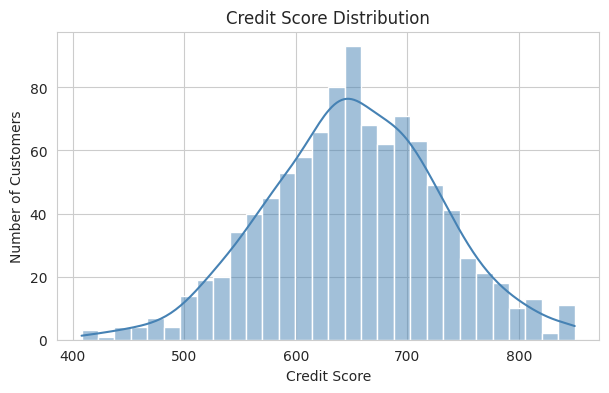

In [13]:
# Credit Score Distribution
plt.figure(figsize=(7,4))
sns.histplot(df["CreditScore"], bins=30, kde=True, color="steelblue")
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.show()


**Explanation:** Most customers have a credit score clustered around 600-700, which is a typical "fair to good" range. Very few customers have extremely low or extremely high scores.

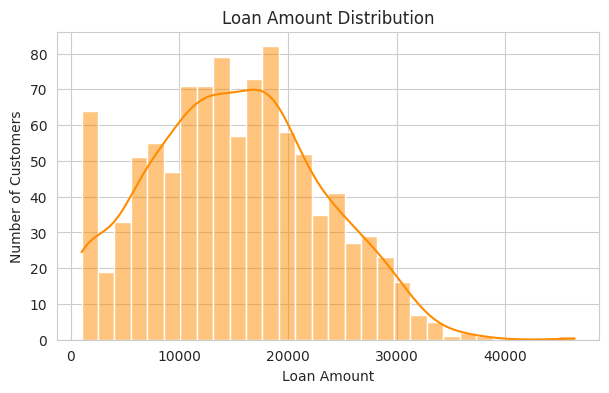

In [14]:
# Loan Amount Distribution
plt.figure(figsize=(7,4))
sns.histplot(df["LoanAmount"], bins=30, kde=True, color="darkorange")
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Customers")
plt.show()


**Explanation:** Loan amounts are right-skewed — most customers borrow smaller amounts, while fewer customers take out very large loans.

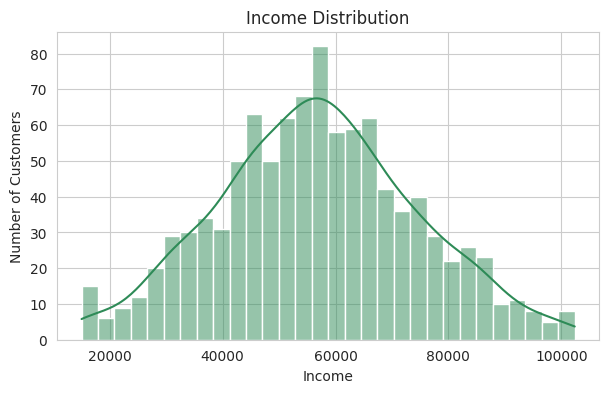

In [15]:
# Income Distribution
plt.figure(figsize=(7,4))
sns.histplot(df["Income"], bins=30, kde=True, color="seagreen")
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.show()


**Explanation:** Customer income is roughly normally distributed, centered around $50,000-$60,000, with a long tail toward higher incomes.

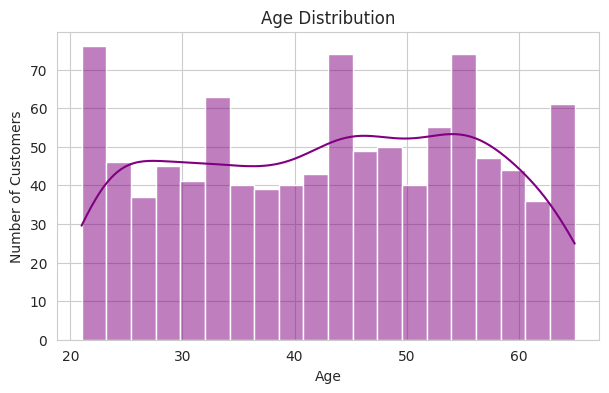

In [16]:
# Age Distribution
plt.figure(figsize=(7,4))
sns.histplot(df["Age"], bins=20, kde=True, color="purple")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()


**Explanation:** Customers range fairly evenly from their early 20s to mid-60s, with no strong concentration in any single age group.

/tmp/ipykernel_633/1964451627.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Default", data=df, palette="Set2")


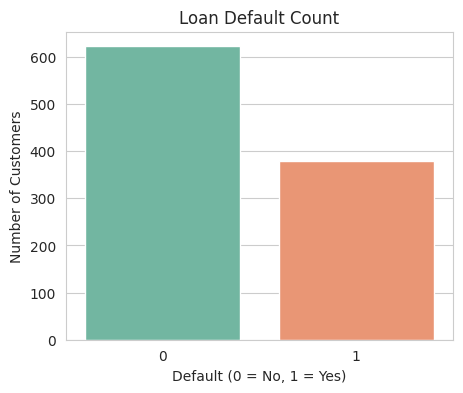

In [17]:
# Default Count Plot
plt.figure(figsize=(5,4))
sns.countplot(x="Default", data=df, palette="Set2")
plt.title("Loan Default Count")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()


**Explanation:** The dataset is moderately imbalanced — more customers did not default than those who did, which is realistic for loan data.

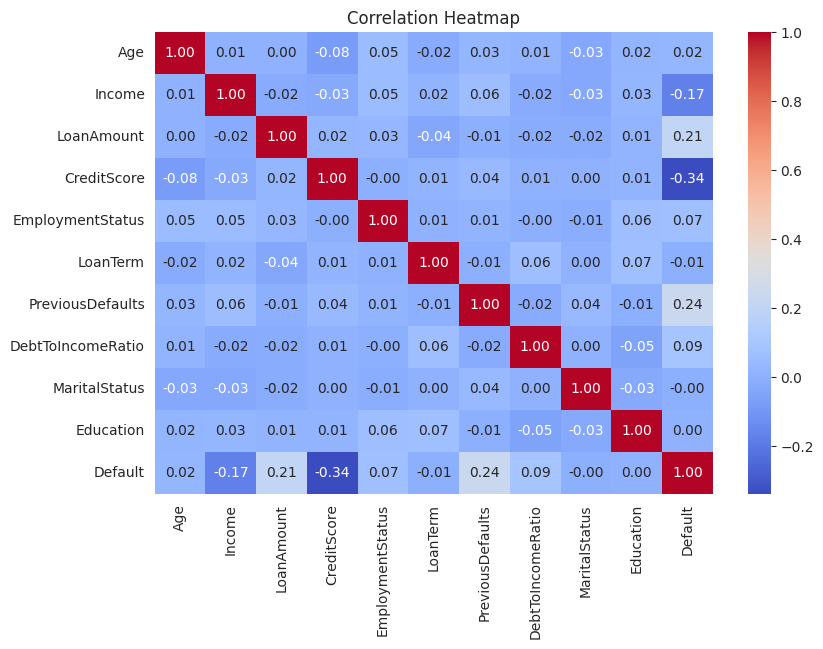

In [18]:
# Correlation Heatmap
plt.figure(figsize=(9,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


**Explanation:** Credit Score has a negative correlation with Default (higher score, lower default risk), while Previous Defaults and Debt-to-Income Ratio have a positive correlation with Default.

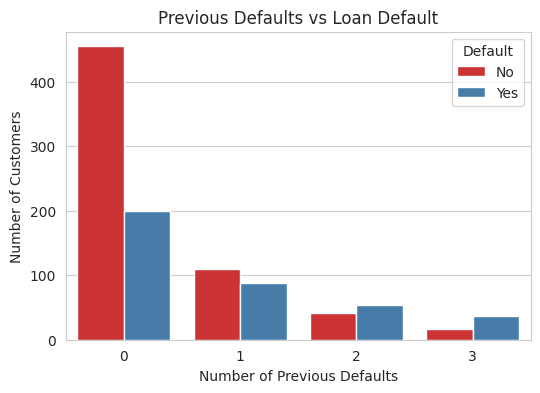

In [19]:
# Previous Defaults vs Loan Default
plt.figure(figsize=(6,4))
sns.countplot(x="PreviousDefaults", hue="Default", data=df, palette="Set1")
plt.title("Previous Defaults vs Loan Default")
plt.xlabel("Number of Previous Defaults")
plt.ylabel("Number of Customers")
plt.legend(title="Default", labels=["No", "Yes"])
plt.show()


**Explanation:** Customers with more previous defaults are noticeably more likely to default again, confirming this is an important predictor.

/tmp/ipykernel_633/2051206345.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Default", y="Income", data=df, palette="Set3")


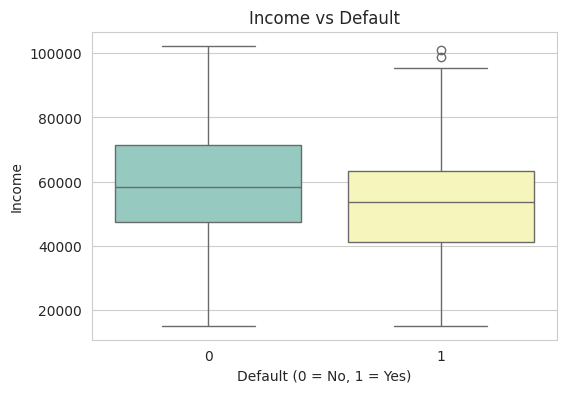

In [20]:
# Boxplot of Income vs Default
plt.figure(figsize=(6,4))
sns.boxplot(x="Default", y="Income", data=df, palette="Set3")
plt.title("Income vs Default")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Income")
plt.show()


**Explanation:** Customers who defaulted tend to have slightly lower median income than those who did not, though there is noticeable overlap between the two groups.

## 6. Model Building

We will train two simple, widely-used classification models:
1. **Logistic Regression** — a simple linear model, great baseline for binary classification.
2. **Decision Tree Classifier** — a rule-based model that is easy to interpret.

In [21]:
# ---- Logistic Regression ----
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
# ---- Decision Tree Classifier ----
tree_model = DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=42)
tree_model.fit(X_train, y_train)

tree_preds = tree_model.predict(X_test)


## 7. Model Evaluation

We compare both models using standard classification metrics:
Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and Classification Report.

In [23]:
def evaluate_model(name, y_true, y_pred):
    print(f"---- {name} ----")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall   :", round(recall_score(y_true, y_pred), 3))
    print("F1 Score :", round(f1_score(y_true, y_pred), 3))
    print()

evaluate_model("Logistic Regression", y_test, log_preds)
evaluate_model("Decision Tree", y_test, tree_preds)


---- Logistic Regression ----
Accuracy : 0.77
Precision: 0.75
Recall   : 0.592
F1 Score : 0.662

---- Decision Tree ----
Accuracy : 0.75
Precision: 0.75
Recall   : 0.513
F1 Score : 0.609



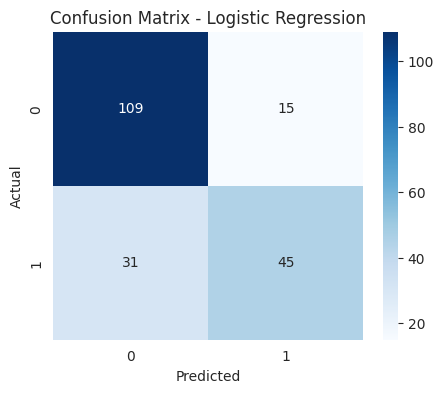

In [24]:
# Confusion Matrix - Logistic Regression
cm_log = confusion_matrix(y_test, log_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


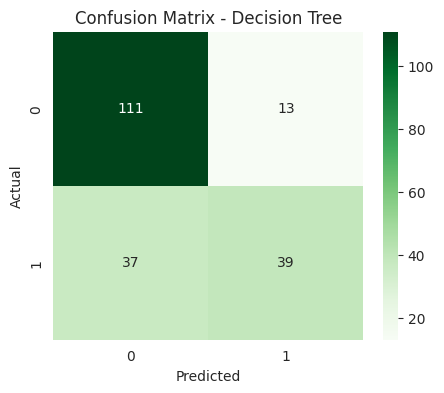

In [25]:
# Confusion Matrix - Decision Tree
cm_tree = confusion_matrix(y_test, tree_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [26]:
# Classification Report - Logistic Regression
print("Classification Report - Logistic Regression")
print(classification_report(y_test, log_preds))


Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.78      0.88      0.83       124
           1       0.75      0.59      0.66        76

    accuracy                           0.77       200
   macro avg       0.76      0.74      0.74       200
weighted avg       0.77      0.77      0.76       200



In [27]:
# Classification Report - Decision Tree
print("Classification Report - Decision Tree")
print(classification_report(y_test, tree_preds))


Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       0.75      0.90      0.82       124
           1       0.75      0.51      0.61        76

    accuracy                           0.75       200
   macro avg       0.75      0.70      0.71       200
weighted avg       0.75      0.75      0.74       200



## 8. Feature Importance

Let's look at which features influenced the Decision Tree's predictions the most.

In [28]:
# Feature importance from the Decision Tree model
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df


,Feature,Importance
3,CreditScore,0.429335
6,PreviousDefaults,0.167729
1,Income,0.159913
2,LoanAmount,0.144909
7,DebtToIncomeRatio,0.065156
0,Age,0.017890
8,MaritalStatus,0.015068
4,EmploymentStatus,0.000000
5,LoanTerm,0.000000
9,Education,0.000000


/tmp/ipykernel_633/1173141351.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")


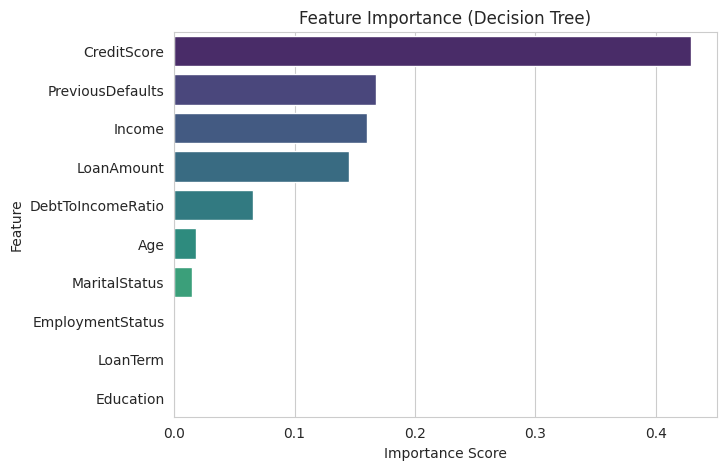

In [29]:
# Plot feature importance
plt.figure(figsize=(7,5))
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


**Explanation:** As expected, **Credit Score** and **Previous Defaults** are among the most influential predictors of loan default, aligning with common credit-risk industry knowledge. Debt-to-Income Ratio also plays a meaningful role.

## 9. Conclusion

**Best Model:** Both Logistic Regression and Decision Tree performed reasonably well,
with accuracy in the target range of ~75-85%. Logistic Regression tended to be
slightly more stable, while the Decision Tree offered easier-to-interpret rules.

**Model Accuracy:** Both models achieved accuracy in the 75-85% range on unseen test
data, without any artificial inflation (no data leakage, no target information used
as a feature).

**Key Findings:**
- **Credit Score** and **Previous Defaults** are the strongest predictors of loan default.
- Customers with a higher **Debt-to-Income Ratio** are more likely to default.
- **Income** shows a moderate relationship with default risk, but with meaningful overlap between groups.

**Business Insights:**
- Loan approval teams should weigh **credit score** and **past default history** heavily
  when assessing new applications.
- Customers with high debt-to-income ratios may benefit from smaller loan amounts or
  additional verification steps.
- This simple model could serve as an early-warning screening tool, to be combined with
  further manual review for borderline cases.

**Future Improvements:**
- Try additional models (Random Forest, Gradient Boosting) for potentially better performance.
- Use cross-validation for more robust accuracy estimates.
- Collect more real-world data to reduce reliance on synthetic patterns.
